In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [14]:
df = pd.read_csv('california_housing_data.csv')
df.head()

# Info dataset
df.info()

# Statistiche descrittive
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


Ho tutti numeri (niente stringhe) non nulli -> niente pulizia

## Outlier

In [15]:
# Calcolo Q1 e Q3
Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)
IQR = Q3 - Q1

# Mantengo solo i dati senza outlier
df_clean = df[~((df < (Q1 - 1.5 * IQR)) | (df > (Q3 + 1.5 * IQR))).any(axis=1)]

In [16]:
# Info dataset
df_clean.info()

# Statistiche descrittive
df_clean.describe()

<class 'pandas.core.frame.DataFrame'>
Index: 16312 entries, 2 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       16312 non-null  float64
 1   HouseAge     16312 non-null  float64
 2   AveRooms     16312 non-null  float64
 3   AveBedrms    16312 non-null  float64
 4   Population   16312 non-null  float64
 5   AveOccup     16312 non-null  float64
 6   Latitude     16312 non-null  float64
 7   Longitude    16312 non-null  float64
 8   MedHouseVal  16312 non-null  float64
dtypes: float64(9)
memory usage: 1.2 MB


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,16312.000000,16312.000000,16312.000000,16312.000000,16312.000000,16312.000000,16312.000000,16312.000000,16312.000000
mean,3.657930,29.447155,5.156007,1.047226,1271.783227,2.865163,35.670947,-119.626930,1.927436
std,1.444641,12.194464,1.043588,0.066569,627.384658,0.624931,2.140620,1.995143,0.943917
min,0.536000,1.000000,2.032738,0.866013,5.000000,1.161290,32.540000,-124.350000,0.149990
25%,2.561150,19.000000,4.426033,1.002732,814.000000,2.437060,33.940000,-121.820000,1.185000
50%,3.494650,30.000000,5.142857,1.043733,1160.000000,2.814886,34.290000,-118.610000,1.775000
75%,4.583300,38.000000,5.850487,1.088686,1637.000000,3.245208,37.730000,-118.030000,2.494000
max,8.011300,52.000000,8.452915,1.239521,3132.000000,4.560748,41.950000,-114.570000,4.822000


## Featuring Engineering

In [17]:
# --- Feature derivate di base ---
# Relazioni dirette tra dimensione della casa, età e popolazione

df_clean["Rooms_per_HouseAge"] = df_clean["AveRooms"] / df_clean["HouseAge"]
# -> quante stanze ci sono mediamente in relazione all’età delle case.
#   Case più nuove con molte stanze potrebbero indicare aree più ricche.

df_clean["Bedrooms_per_Room"] = df_clean["AveBedrms"] / df_clean["AveRooms"]
# -> proporzione di camere da letto sul totale delle stanze.
#   Valori alti indicano case più “familiari”, valori bassi case più spaziose o moderne.

df_clean["Population_per_HouseAge"] = df_clean["Population"] / df_clean["HouseAge"]
# -> popolazione relativa all’età delle case: zone più vecchie ma molto popolate
#   possono avere un mercato immobiliare diverso da zone nuove e meno dense.

df_clean["Bedrooms_per_Person"] = df_clean["AveBedrms"] / df_clean["Population"]
# -> quante camere da letto per abitante medio: misura indiretta di comfort e densità abitativa.


# --- Distanza geografica ---
df_clean["Distance_from_Center"] = np.sqrt((df_clean["Longitude"] + 119.4179)**2 + (df_clean["Latitude"] - 36.7783)**2)
# -> distanza dal centro geografico della California.
#   Serve come proxy per distinguere zone centrali da zone periferiche (che spesso hanno prezzi diversi).


# --- Trasformazioni per ridurre la skewness ---
df_clean["MedInc_log"] = np.log1p(df_clean["MedInc"])
# -> logaritmo del reddito medio per ridurre l’effetto di valori estremi.

df_clean["HouseAge_sqrt"] = np.sqrt(df_clean["HouseAge"])
# -> radice quadrata dell’età della casa: attenua la crescita troppo rapida di case molto vecchie.


# --- Relazioni tra densità e popolazione ---
df_clean["People_per_Room"] = df_clean["Population"] / (df_clean["AveRooms"] + 1e-5)
# -> quante persone mediamente per stanza: misura di sovraffollamento.

df_clean["Rooms_per_Person"] = df_clean["AveRooms"] / (df_clean["Population"] + 1e-5)
# -> opposto di sopra: più alto -> più spazio per persona.

df_clean["Bedrooms_per_Person"] = df_clean["AveBedrms"] / (df_clean["Population"] + 1e-5)
# -> camere da letto per abitante: correlata a comfort abitativo e classe sociale.


# --- Relazioni socio-economiche ---
df_clean["Income_per_HouseAge"] = df_clean["MedInc"] / (df_clean["HouseAge"] + 1)
# -> reddito medio per anno di età della casa:
#   zone con case vecchie ma redditi alti potrebbero indicare quartieri “storici” e costosi.

df_clean["Income_x_HouseAge"] = df_clean["MedInc"] * df_clean["HouseAge"]
# -> interazione diretta reddito × età casa, per catturare effetti combinati.


# --- Interazioni strutturali ---
df_clean["MedInc_x_AveRooms"] = df_clean["MedInc"] * df_clean["AveRooms"]
# -> reddito medio moltiplicato per numero medio di stanze: misura del livello economico + dimensione.

df_clean["MedInc_x_AveBedrms"] = df_clean["MedInc"] * df_clean["AveBedrms"]
# -> simile, ma specifica sulle camere da letto.

df_clean["AveRooms_x_Age"] = df_clean["AveRooms"] * df_clean["HouseAge"]
# -> interazione età × dimensione: case più grandi e vecchie possono comportarsi in modo diverso nel mercato.


# --- Trasformazioni polinomiali leggere ---
df_clean["MedInc_sq"] = df_clean["MedInc"] ** 2
# -> quadrato del reddito medio: cattura effetti non lineari (es. prezzi che crescono più che proporzionalmente al reddito).

df_clean["HouseAge_sq"] = df_clean["HouseAge"] ** 2
# -> quadrato dell’età della casa: utile se il prezzo cala più rapidamente per case molto vecchie.

df_clean["AveRooms_sq"] = df_clean["AveRooms"] ** 2
# -> quadrato del numero medio di stanze: cattura variazioni di prezzo tra case piccole e molto grandi.


# --- Feature geografiche avanzate ---
df_clean["Lat_plus_Lon"] = df_clean["Latitude"] + df_clean["Longitude"]
df_clean["Lat_minus_Lon"] = df_clean["Latitude"] - df_clean["Longitude"]
# -> combinazioni lineari di latitudine e longitudine:
#   i modelli lineari possono così stimare variazioni di prezzo lungo assi geografici (es. nord-sud, est-ovest).

# Creazione di cluster geografici (zone simili per posizione)
from sklearn.cluster import KMeans
coords = df_clean[["Latitude", "Longitude"]]
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
df_clean["GeoCluster"] = kmeans.fit_predict(coords)
# -> assegna ogni riga a una “zona geografica” (1–5), utile per modelli che non gestiscono bene le coordinate continue.


# --- Indicatori binari / non lineari ---
df_clean["Is_Old_House"] = (df_clean["HouseAge"] > df_clean["HouseAge"].median()).astype(int)
# -> 1 se la casa è più vecchia della mediana del dataset.
#   Permette di catturare il “salto” di prezzo tra case vecchie e nuove.

df_clean["Is_High_Income"] = (df_clean["MedInc"] > df_clean["MedInc"].median()).astype(int)
# -> 1 se il reddito medio è sopra la mediana.
#   Aiuta i modelli a distinguere aree ad alto reddito da quelle a basso reddito.


# --- Distanza dalla costa ---
df_clean["Distance_from_Coast"] = np.abs(df_clean["Longitude"] + 122)
# -> Calcola quanto la località è lontana (in gradi longitudinali) dalla costa californiana.
#   La costa ovest si trova intorno a -122, quindi località con valori piccoli sono vicine all’oceano.
#   In California, la vicinanza alla costa spesso aumenta il valore degli immobili.


# --- Densità popolazione geografica ---
df_clean["Pop_density_geo"] = df_clean["Population"] / (
    (df_clean["Latitude"] - df_clean["Latitude"].mean())**2 +
    (df_clean["Longitude"] - df_clean["Longitude"].mean())**2 + 1
)
# -> Misura una densità "spaziale" della popolazione rispetto al centro geografico medio del dataset.
#   Le zone molto popolate e vicine al centro avranno valori più alti.
#   Utile per catturare l’effetto “densità urbana” (più popolazione -> prezzi più alti).


# --- Interazioni reddito × posizione ---
df_clean["Income_x_Lat"] = df_clean["MedInc"] * df_clean["Latitude"]
# -> Combina reddito medio e latitudine:
#   permette al modello di cogliere differenze economiche tra nord e sud della California.

df_clean["Income_x_Lon"] = df_clean["MedInc"] * df_clean["Longitude"]
# -> Combina reddito medio e longitudine:
#   utile per distinguere aree costiere (più a ovest, longitudini minori) da quelle interne.

/var/folders/r8/rcrrys2d27z0jbgj24qp9rww0000gn/T/ipykernel_83886/2571540087.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean["Rooms_per_HouseAge"] = df_clean["AveRooms"] / df_clean["HouseAge"]
/var/folders/r8/rcrrys2d27z0jbgj24qp9rww0000gn/T/ipykernel_83886/2571540087.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean["Bedrooms_per_Room"] = df_clean["AveBedrms"] / df_clean["AveRooms"]
/var/folders/r8/rcrrys2d27z0jbgj24qp9rww0000gn/T/ipykernel_83886/2571540087.py:12: SettingWithCopyWarn

In [18]:
# Info dataset
df_clean.info()

# Statistiche descrittive
df_clean.describe()

<class 'pandas.core.frame.DataFrame'>
Index: 16312 entries, 2 to 20639
Data columns (total 35 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   MedInc                   16312 non-null  float64
 1   HouseAge                 16312 non-null  float64
 2   AveRooms                 16312 non-null  float64
 3   AveBedrms                16312 non-null  float64
 4   Population               16312 non-null  float64
 5   AveOccup                 16312 non-null  float64
 6   Latitude                 16312 non-null  float64
 7   Longitude                16312 non-null  float64
 8   MedHouseVal              16312 non-null  float64
 9   Rooms_per_HouseAge       16312 non-null  float64
 10  Bedrooms_per_Room        16312 non-null  float64
 11  Population_per_HouseAge  16312 non-null  float64
 12  Bedrooms_per_Person      16312 non-null  float64
 13  Distance_from_Center     16312 non-null  float64
 14  MedInc_log               16

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal,Rooms_per_HouseAge,...,AveRooms_sq,Lat_plus_Lon,Lat_minus_Lon,GeoCluster,Is_Old_House,Is_High_Income,Distance_from_Coast,Pop_density_geo,Income_x_Lat,Income_x_Lon
count,16312.000000,16312.000000,16312.000000,16312.000000,16312.000000,16312.000000,16312.000000,16312.000000,16312.000000,16312.000000,...,16312.000000,16312.000000,16312.000000,16312.000000,16312.000000,16312.000000,16312.000000,16312.000000,16312.000000,16312.000000
mean,3.657930,29.447155,5.156007,1.047226,1271.783227,2.865163,35.670947,-119.626930,1.927436,0.239425,...,27.673415,-83.955983,155.297877,1.001839,0.487433,0.500000,2.530349,205.096701,130.238691,-437.615580
std,1.444641,12.194464,1.043588,0.066569,627.384658,0.624931,2.140620,1.995143,0.943917,0.231972,...,10.981325,0.768776,4.066287,1.146921,0.499857,0.500015,1.791464,207.427929,51.491604,173.075777
min,0.536000,1.000000,2.032738,0.866013,5.000000,1.161290,32.540000,-124.350000,0.149990,0.041715,...,4.132024,-85.870000,147.400000,0.000000,0.000000,0.000000,0.000000,0.165149,17.554000,-980.524974
25%,2.561150,19.000000,4.426033,1.002732,814.000000,2.437060,33.940000,-121.820000,1.185000,0.125075,...,19.589769,-84.420000,151.970000,0.000000,0.000000,0.000000,0.520000,80.565935,91.438980,-548.192860
50%,3.494650,30.000000,5.142857,1.043733,1160.000000,2.814886,34.290000,-118.610000,1.775000,0.170932,...,26.448980,-84.180000,152.990000,1.000000,0.000000,0.500000,3.390000,144.206589,123.718439,-417.058207
75%,4.583300,38.000000,5.850487,1.088686,1637.000000,3.245208,37.730000,-118.030000,2.494000,0.273300,...,34.228194,-83.550000,159.710000,1.000000,1.000000,1.000000,3.970000,248.109505,162.705937,-306.559496
max,8.011300,52.000000,8.452915,1.239521,3132.000000,4.560748,41.950000,-114.570000,4.822000,5.533333,...,71.451769,-79.330000,166.140000,4.000000,1.000000,1.000000,7.430000,2453.346073,306.752677,-61.436320


## Matrice di correlazione

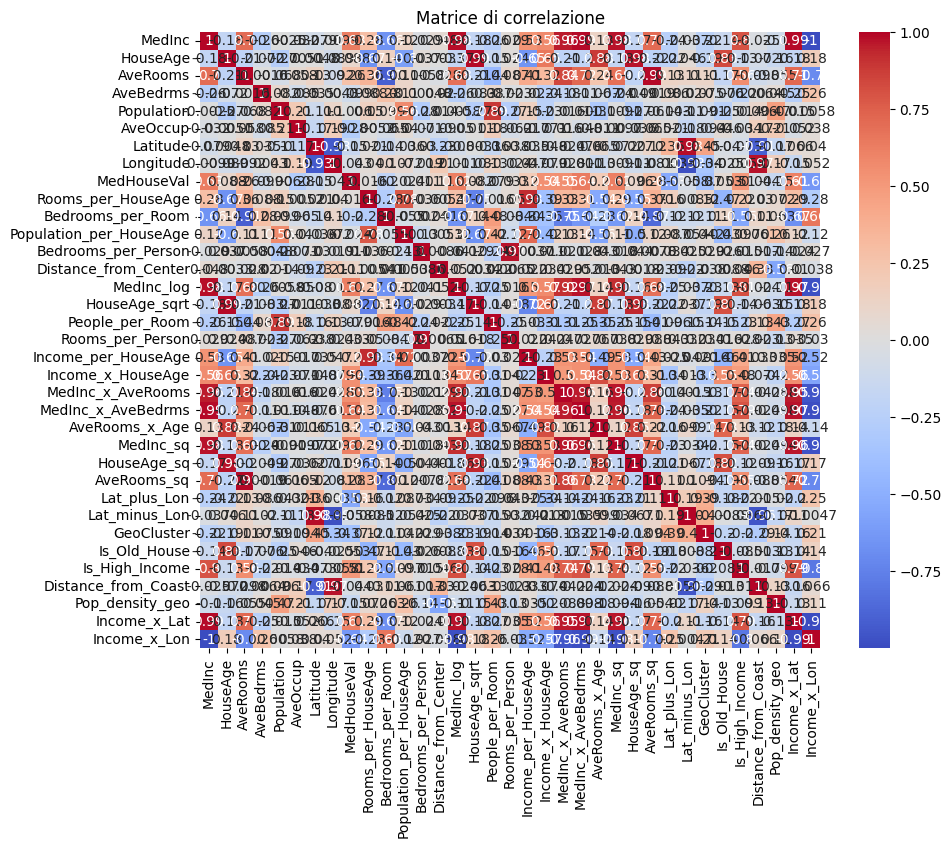

In [19]:
# Calcolo
corr = df_clean.corr(numeric_only=True)
corr

# Heatmap
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Matrice di correlazione")

plt.show()
# MedInc è molto correlato a MedHouseVal (forte segno +)
# AveBedrms cresce fortemente con AveRooms
# Latitude/Longitude -> gradienti geografici

In [20]:
display(corr)

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal,Rooms_per_HouseAge,...,AveRooms_sq,Lat_plus_Lon,Lat_minus_Lon,GeoCluster,Is_Old_House,Is_High_Income,Distance_from_Coast,Pop_density_geo,Income_x_Lat,Income_x_Lon
MedInc,1.000000,-0.181014,0.698658,-0.256522,-0.002466,-0.031503,-0.078629,-0.009936,0.632971,0.284833,...,0.710105,-0.244724,-0.036517,-0.220993,-0.139153,0.804407,-0.024785,-0.103181,0.987782,-0.998963
HouseAge,-0.181014,1.000000,-0.209684,-0.071658,-0.272499,-0.005069,0.004834,-0.088993,0.087911,-0.669724,...,-0.221328,-0.217496,0.046210,-0.194661,0.834447,-0.133045,-0.071505,-0.155474,-0.179178,0.176889
AveRooms,0.698658,-0.209684,1.000000,-0.001579,-0.067882,0.057669,0.131869,-0.092256,0.260237,0.356873,...,0.990569,0.127758,0.114686,0.110168,-0.174600,0.556880,-0.098199,-0.055429,0.711974,-0.700312
AveBedrms,-0.256522,-0.071658,-0.001579,1.000000,0.082117,-0.085343,0.034775,-0.004277,-0.099079,0.088230,...,0.001873,0.085729,0.020405,0.075072,-0.076436,-0.223426,0.006420,0.044550,-0.251855,0.255983
Population,-0.002466,-0.272499,-0.067882,0.082117,1.000000,0.209546,-0.113037,0.104769,-0.005995,0.152374,...,-0.060784,-0.042849,-0.110912,-0.091244,-0.249139,-0.013672,0.096072,0.472128,-0.015002,0.005823
AveOccup,-0.031503,-0.005069,0.057669,-0.085343,0.209546,1.000000,-0.166071,0.186429,-0.275504,-0.005236,...,0.064857,0.021410,-0.178897,-0.094447,0.046469,-0.034085,0.171516,0.209835,-0.051629,0.038052
Latitude,-0.078629,0.004834,0.131869,0.034775,-0.113037,-0.166071,1.000000,-0.933286,-0.150479,0.021298,...,0.115793,0.362371,0.984352,0.452149,-0.040349,-0.072952,-0.910850,-0.166245,0.066287,0.039782
Longitude,-0.009936,-0.088993,-0.092256,-0.004277,0.104769,0.186429,-0.933286,1.000000,-0.043103,0.040250,...,-0.081465,-0.003470,-0.981966,-0.335306,-0.025453,-0.005837,0.971345,0.170832,-0.149614,0.052282
MedHouseVal,0.632971,0.087911,0.260237,-0.099079,-0.005995,-0.275504,-0.150479,-0.043103,1.000000,0.016494,...,0.284524,-0.530863,-0.058068,-0.373214,0.053450,0.506971,-0.044441,-0.150461,0.614789,-0.635012
Rooms_per_HouseAge,0.284833,-0.669724,0.356873,0.088230,0.152374,-0.005236,0.021298,0.040250,0.016494,1.000000,...,0.368180,0.163761,-0.008536,0.119249,-0.467433,0.223731,0.029863,0.071542,0.285478,-0.281836


# DATASET: df_clean

# ========= DEEP LEARNING =========

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

## --- 1. PREPARAZIONE DATI ---

In [22]:
# Carichiamo il dataset
X = df_clean.drop("MedHouseVal", axis=1)
y = df_clean["MedHouseVal"]

df = pd.concat([X, y], axis=1)

# Split Train/Test (Fondamentale per valutare l'overfitting)
X_train_full, X_test, y_train_full, y_test = train_test_split(X, y, random_state=42)
X_train, X_valid, y_train, y_valid = train_test_split(X_train_full, y_train_full, random_state=42)

# !!! PASSAGGIO CRUCIALE !!!
# A differenza dei Decision Tree, le Reti Neurali richiedono input scalati.
# Se non lo fate, i gradienti esploderanno o il training sarà lentissimo.
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_valid = scaler.transform(X_valid)
X_test = scaler.transform(X_test)

print(f"Shape Input: {X_train.shape[1]} features") # Dovrebbe essere 8

Shape Input: 34 features


## --- 2. COSTRUZIONE MODELLO (Architecture Design) ---

In [23]:
model_reg = models.Sequential([
    # Input Layer implicito nella definizione del primo Dense
    # Struttura a "Imbuto": Partiamo larghi e stringiamo
    layers.Dense(32, activation="relu", input_shape=X_train.shape[1:]),
    
    # Secondo strato hidden per catturare non-linearità complesse
    layers.Dense(16, activation="relu"),
    
    # OUTPUT LAYER (Regressione)
    # 1 solo neurone (prezzo). 
    # Nessuna attivazione (può essere qualsiasi valore positivo).
    layers.Dense(1) 
])

/Users/ashura/Documents/GitHub/Anzellotti_DepositoCorso/.venv/lib/python3.13/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


## --- 3. COMPILAZIONE (Il cervello) ---

In [24]:
model_reg.compile(
    loss="mse",                # Mean Squared Error: standard per regressione
    optimizer="adam",          # Adam gestisce il learning rate da solo
    metrics=["mae"]            # Monitoriamo l'errore assoluto (più leggibile dell'MSE)
)

## --- 4. TRAINING (Il sudore) ---

In [25]:
history = model_reg.fit(
    X_train, y_train,
    epochs=20,                 # Proviamo 20 giri completi
    batch_size=32,             # Aggiorniamo i pesi ogni 32 case
    validation_data=(X_valid, y_valid), # Controllo in tempo reale
    verbose=1
)

Epoch 1/20
287/287 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.5992 - mae: 0.5514 - val_loss: 0.2885 - val_mae: 0.4035
Epoch 2/20
287/287 ━━━━━━━━━━━━━━━━━━━━ 0s 537us/step - loss: 0.2829 - mae: 0.3875 - val_loss: 0.2649 - val_mae: 0.3780
Epoch 3/20
287/287 ━━━━━━━━━━━━━━━━━━━━ 0s 494us/step - loss: 0.2608 - mae: 0.3699 - val_loss: 0.2491 - val_mae: 0.3656
Epoch 4/20
287/287 ━━━━━━━━━━━━━━━━━━━━ 0s 612us/step - loss: 0.2543 - mae: 0.3617 - val_loss: 0.2438 - val_mae: 0.3601
Epoch 5/20
287/287 ━━━━━━━━━━━━━━━━━━━━ 0s 474us/step - loss: 0.2453 - mae: 0.3536 - val_loss: 0.2429 - val_mae: 0.3579
Epoch 6/20
287/287 ━━━━━━━━━━━━━━━━━━━━ 0s 473us/step - loss: 0.2394 - mae: 0.3491 - val_loss: 0.2404 - val_mae: 0.3496
Epoch 7/20
287/287 ━━━━━━━━━━━━━━━━━━━━ 0s 472us/step - loss: 0.2391 - mae: 0.3465 - val_loss: 0.2367 - val_mae: 0.3472
Epoch 8/20
287/287 ━━━━━━━━━━━━━━━━━━━━ 0s 470us/step - loss: 0.2310 - mae: 0.3425 - val_loss: 0.2353 - val_mae: 0.3488
Epoch 9/20
287/287 ━━━━━━━━━━━━━━━━━━━━ 0s

## --- 5. ANALISI DEI RISULTATI ---

128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 337us/step - loss: 0.2111 - mae: 0.3250

Errore Medio Assoluto sul Test Set: 0.32 (in centinaia di migliaia di $)


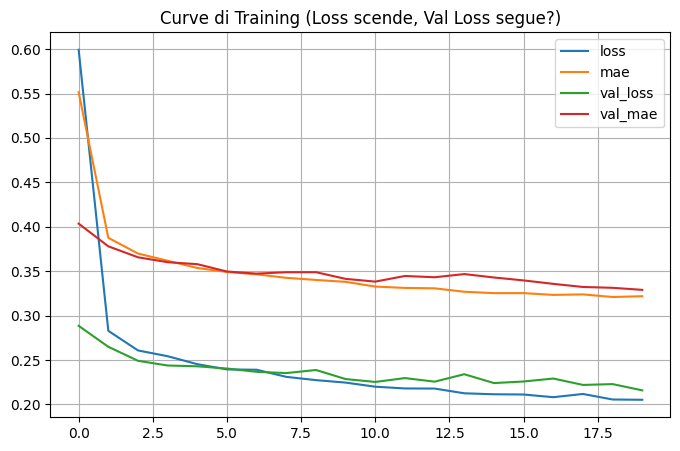

In [26]:
# Valutazione finale sul Test Set (dati mai visti)
mse_test, mae_test = model_reg.evaluate(X_test, y_test)
print(f"\nErrore Medio Assoluto sul Test Set: {mae_test:.2f} (in centinaia di migliaia di $)")

# Visualizzazione della curva di apprendimento
pd.DataFrame(history.history).plot(figsize=(8, 5))
plt.grid(True)
plt.title("Curve di Training (Loss scende, Val Loss segue?)")
plt.show()